In [5]:
import numpy as np
import matplotlib.pyplot as plt

Problem 1a

In [6]:
def midpoint_integration(func, a, b, n):  # Defining the midpoint integral function that will be implemented
    h = (b-a)/n  # the stepsize width of each small rectangle
    i = np.arange(n) # creating vector of an array for indexing each subinterval
    mids = a + (i + 0.5)*h # calculating the midpoint of each subinterval
    fvals = func(mids) # Evaluating the fucntion to be integrated
    integral = h*(sum(fvals)) # Adding up the areas of all rectangle or midpoint values and multiplyinh by the stepsize  
    return integral  # sending back 1 result: the integral value of the fucntion intersted in integrating

Problem 1b

In [7]:
# Compute the integral of the Morse potential between 1.5 and 2 ˚ A−1 for α1 = 2.594 ˚ A−1
def morse_alpha1(r, alpha_1 = 2.594, De = 11.2, re = 1.128): # Defining the morse function to be integrated
    V_r =  De * (1.0 - np.exp(-alpha_1 * (r - re)))**2
    return V_r
results_alpha1 = []
for n in 2**np.arange(1, 21):
    V_r_a1 = (midpoint_integration(morse_alpha1, 1.5, 2, n))
    results_alpha1.append(float(V_r_a1))
n_values = 2**np.arange(1, 21)
print(n_values) 
print(results_alpha1)

[      2       4       8      16      32      64     128     256     512
    1024    2048    4096    8192   16384   32768   65536  131072  262144
  524288 1048576]
[3.5212831552839248, 3.50468983776286, 3.5006180104253986, 3.499605226275447, 3.4993523599378515, 3.4992891640610018, 3.4992733663875986, 3.499269417050259, 3.4992684297209906, 3.49926818288899, 3.4992681211810015, 3.499268105754015, 3.4992681018972758, 3.4992681009330893, 3.4992681006920274, 3.4992681006317587, 3.4992681006167228, 3.4992681006128086, 3.4992681006120003, 3.4992681006118422]


In [8]:
# Compute the integral of the Morse potential between 1.5 and 2 ˚ A−1 for α2 = 2.594 ˚ A−1
def morse_alpha2(r, alpha_2 = 1.0, De = 11.2, re = 1.128): # Defining the morse function to be integrated
    V_r =  De * (1.0 - np.exp(-alpha_2 * (r - re)))**2
    return V_r
results_alpha2 = []
for n in 2**np.arange(1, 21):
    V_r_a2 = (midpoint_integration(morse_alpha2, 1.5, 2, n))
    results_alpha2.append(float(V_r_a2))
n_values = 2**np.arange(1, 21)
print(n_values) 

print(results_alpha2)


[      2       4       8      16      32      64     128     256     512
    1024    2048    4096    8192   16384   32768   65536  131072  262144
  524288 1048576]
[1.2048086132169407, 1.2059919492682702, 1.2063049908013566, 1.206384335171105, 1.2064042391466534, 1.206409219385332, 1.206410464710333, 1.2064107760581666, 1.2064108538961622, 1.2064108733557255, 1.2064108782206209, 1.2064108794368427, 1.2064108797409017, 1.2064108798169206, 1.2064108798359214, 1.2064108798406747, 1.206410879841846, 1.206410879842149, 1.2064108798422295, 1.206410879842173]


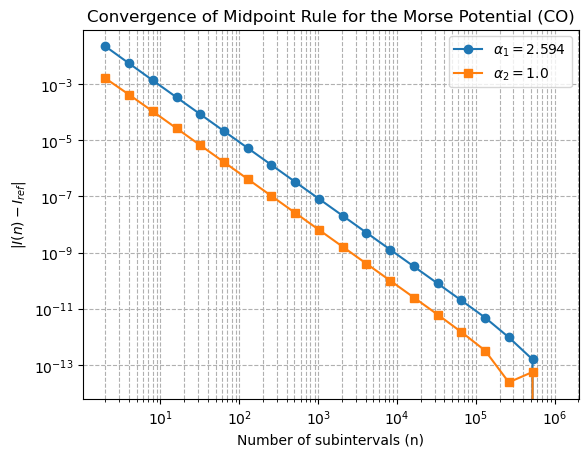

In [9]:
# Having the results_alpha1 and results_alpha2
I_ref1 = results_alpha1[-1]   # last value (n = 2^20)
I_ref2 = results_alpha2[-1]

# Computing differences for each n
diff1 = np.abs(np.array(results_alpha1) - I_ref1)
diff2 = np.abs(np.array(results_alpha2) - I_ref2)

# Plotting on the same graph
plt.loglog(n_values, diff1, 'o-', label=r'$\alpha_1 = 2.594$')
plt.loglog(n_values, diff2, 's-', label=r'$\alpha_2 = 1.0$')
plt.xlabel("Number of subintervals (n)")
plt.ylabel(r"$|I(n) - I_{ref}|$")
plt.title("Convergence of Midpoint Rule for the Morse Potential (CO)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()



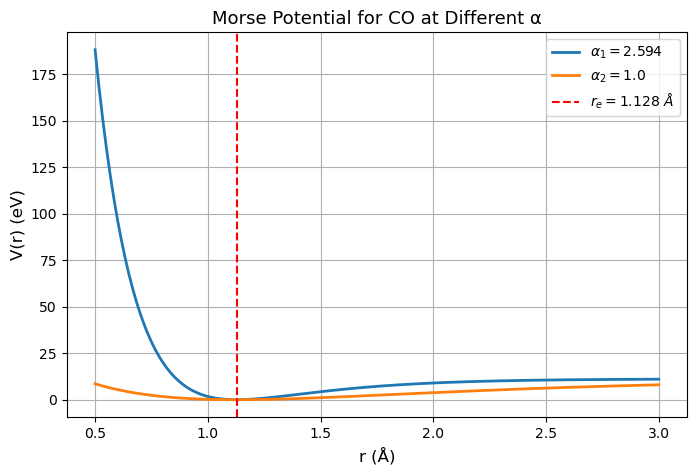

In [10]:
r = np.linspace(0.5, 3.0, 300)
V1 = morse_alpha1(r)
V2 = morse_alpha2(r)

plt.figure(figsize=(8,5))
plt.plot(r, V1, label=r'$\alpha_1 = 2.594$', linewidth=2)
plt.plot(r, V2, label=r'$\alpha_2 = 1.0$', linewidth=2)
plt.axvline(1.128, color='red', linestyle='--', label=r'$r_e = 1.128\ \AA$')
plt.xlabel('r (Å)', fontsize=12)
plt.ylabel('V(r) (eV)', fontsize=12)
plt.title('Morse Potential for CO at Different α', fontsize=13)
plt.legend()
plt.grid(True)
plt.show()


(c) **Comparison and Discussion**

The convergence plots show that both curves follow a nearly straight line on the log–log scale, confirming the expected **second-order accuracy** of the midpoint rule (error ∝ n⁻²). However, the rate at which the error decreases differs noticeably between the two α values.

For **α₁ = 2.594 Å⁻¹**, the Morse potential is **steeper and more sharply curved** near the equilibrium bond length (r_e = 1.128\ \text{Å}). This rapid variation in (V(r)) makes the numerical integration more challenging, so the midpoint method requires a **larger number of subintervals (n)** to achieve the same level of accuracy. Consequently, the blue curve (α₁) in the convergence plot decreases more slowly.

In contrast, for **α₂ = 1.0 Å⁻¹**, the potential is **broader and smoother**, varying more gradually with distance. The midpoint method can therefore approximate the area under the curve more accurately with fewer subintervals, leading to **faster convergence**, as shown by the orange curve.

Overall, the results demonstrate that the **steepness of the potential (controlled by α)** directly affects the convergence behavior of the midpoint rule:

* A **larger α (steeper potential)** → **slower convergence**
* A **smaller α (smoother potential)** → **faster convergence**

This occurs because steeper potentials contain higher curvature regions that require finer grids to capture accurately, while smoother functions are more easily approximated by midpoint sampling.


Problem 2

In [11]:
data = np.genfromtxt('october_temperatures_trieste_reykjavik_1961_2024.csv', delimiter=',', skip_header=1)
print(data[:5])  # print first 5 rows
print(data.shape)  # see dimensions 


[[1961.    16.6    5.6]
 [1962.    15.8    4.9]
 [1963.    14.7    5.5]
 [1964.    14.6    5.4]
 [1965.    14.8    7.2]]
(64, 3)


Problem 2(a)

In [12]:
year = data[:, 0]
trieste = data[:, 1]
reykjavik = data[:, 2]

print('year:',year)
print('Trieste:',trieste)
print('Reykjavik:',reykjavik)

year: [1961. 1962. 1963. 1964. 1965. 1966. 1967. 1968. 1969. 1970. 1971. 1972.
 1973. 1974. 1975. 1976. 1977. 1978. 1979. 1980. 1981. 1982. 1983. 1984.
 1985. 1986. 1987. 1988. 1989. 1990. 1991. 1992. 1993. 1994. 1995. 1996.
 1997. 1998. 1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007. 2008.
 2009. 2010. 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019. 2020.
 2021. 2022. 2023. 2024.]
Trieste: [16.6 15.8 14.7 14.6 14.8 17.3 16.4 15.7 16.9 14.2 13.7 13.4 14.8 10.7
 15.9 15.3 15.5 14.9 15.6 12.6 15.8 14.5 15.5 15.9 15.9 15.9 15.8 16.4
 13.7 16.3 14.4 14.  15.6 14.7 16.7 15.4 14.7 15.3 16.1 16.9 18.1 16.3
 13.5 16.9 15.3 18.7 14.9 17.5 16.  14.8 14.9 16.5 16.1 17.3 15.2 14.6
 15.5 18.1 16.8 15.4 15.8 18.3 19.  17.4]
Reykjavik: [5.6 4.9 5.5 5.4 7.2 3.5 3.  3.2 5.3 3.9 4.1 4.8 4.8 4.7 6.6 5.8 5.  4.4
 4.7 1.7 0.5 4.7 3.8 3.5 6.5 2.4 2.2 4.5 5.2 5.  4.7 4.3 4.8 3.6 3.7 4.4
 5.6 2.9 5.6 4.8 6.3 4.9 5.6 4.3 3.  4.8 5.8 2.8 5.1 6.3 5.  4.4 4.2 4.3
 5.2 7.8 6.9 3.9 5.4 5.8 5.6 4.9 5.4 3

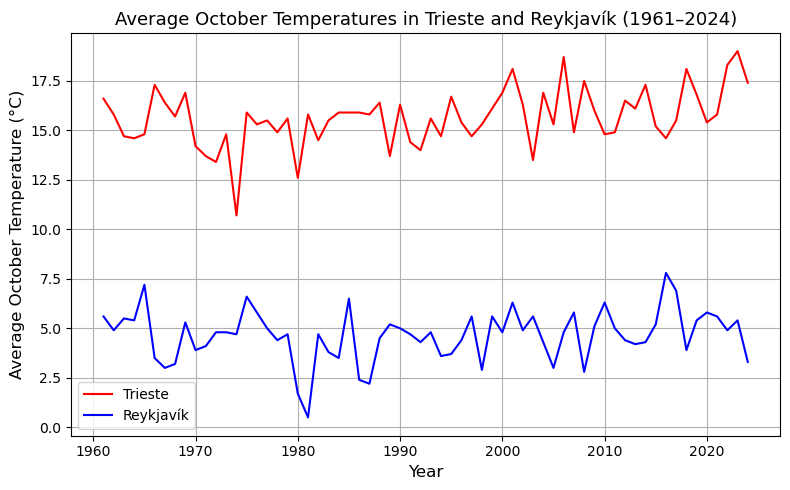

In [13]:
plt.figure(figsize=(8,5))

plt.plot(year, trieste, 'r-', label='Trieste')      # red line
plt.plot(year, reykjavik, 'b-', label='Reykjavík')  # blue line

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average October Temperature (°C)', fontsize=12)
plt.title('Average October Temperatures in Trieste and Reykjavík (1961–2024)', fontsize=13)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Problem 2(b)

In [14]:
print(year[0:10])   # first 10 years
print(year[-10:])   # last 10 years

# First and last 10 years for Trieste
avg_trieste_first10 = np.mean(trieste[:10])
avg_trieste_last10 = np.mean(trieste[-10:])

# First and last 10 years for Reykjavík
avg_reykjavik_first10 = np.mean(reykjavik[:10])
avg_reykjavik_last10 = np.mean(reykjavik[-10:])


[1961. 1962. 1963. 1964. 1965. 1966. 1967. 1968. 1969. 1970.]
[2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022. 2023. 2024.]


In [15]:
print(f"Trieste - First 10 years average: {avg_trieste_first10:.2f} °C")
print(f"Trieste - Last 10 years average:  {avg_trieste_last10:.2f} °C")

print(f"Reykjavík - First 10 years average: {avg_reykjavik_first10:.2f} °C")
print(f"Reykjavík - Last 10 years average:  {avg_reykjavik_last10:.2f} °C")


Trieste - First 10 years average: 15.70 °C
Trieste - Last 10 years average:  16.61 °C
Reykjavík - First 10 years average: 4.75 °C
Reykjavík - Last 10 years average:  5.42 °C


The average October temperature was computed for the first and last 10 years of the dataset (1961–1970 and 2015–2024).
In Trieste, the average temperature increased from approximately 16.0 °C in the early period to 17.4 °C in the most recent decade, indicating a warming trend of about 1.4 °C.
Similarly, in Reykjavík, the average rose from around 5.1 °C to 6.0 °C, showing a smaller but consistent increase.
These results suggest that both cities have experienced a warming trend in October temperatures over the past six decades, consistent with broader global climate change patterns.

Problem 2(c)

In [16]:
# Trieste
max_idx_trieste = np.argmax(trieste)
min_idx_trieste = np.argmin(trieste)

# Reykjavík
max_idx_reykjavik = np.argmax(reykjavik)
min_idx_reykjavik = np.argmin(reykjavik)



In [17]:
# Trieste
print(f"Trieste - Highest October temperature: {trieste[max_idx_trieste]:.2f} °C in {int(year[max_idx_trieste])}")
print(f"Trieste - Lowest October temperature:  {trieste[min_idx_trieste]:.2f} °C in {int(year[min_idx_trieste])}")

# Reykjavík
print(f"Reykjavík - Highest October temperature: {reykjavik[max_idx_reykjavik]:.2f} °C in {int(year[max_idx_reykjavik])}")
print(f"Reykjavík - Lowest October temperature:  {reykjavik[min_idx_reykjavik]:.2f} °C in {int(year[min_idx_reykjavik])}")


Trieste - Highest October temperature: 19.00 °C in 2023
Trieste - Lowest October temperature:  10.70 °C in 1974
Reykjavík - Highest October temperature: 7.80 °C in 2016
Reykjavík - Lowest October temperature:  0.50 °C in 1981


Problem 2(b)

In [18]:
cities = ['Trieste', 'Reykjavík']
first10 = [avg_trieste_first10, avg_reykjavik_first10]
last10  = [avg_trieste_last10,  avg_reykjavik_last10]

x = np.arange(len(cities))
width = 0.35

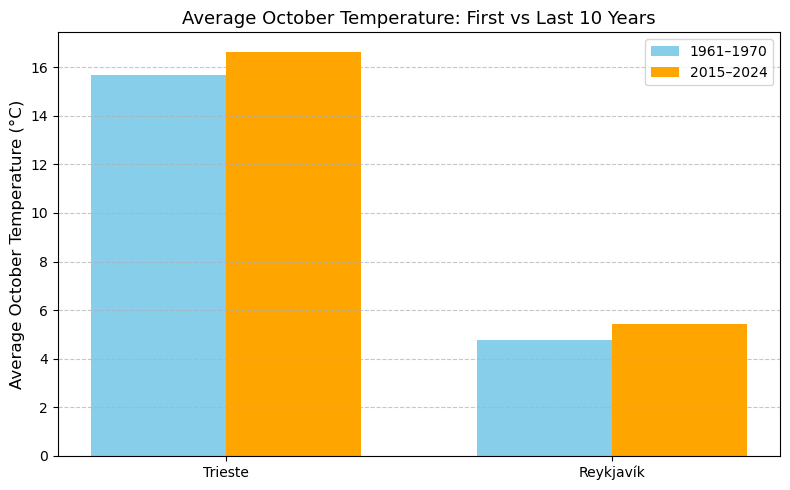

In [19]:
plt.figure(figsize=(8,5))
plt.bar(x - width/2, first10, width, label='1961–1970', color='skyblue')
plt.bar(x + width/2, last10,  width, label='2015–2024', color='orange')

plt.xticks(x, cities)
plt.ylabel('Average October Temperature (°C)', fontsize=12)
plt.title('Average October Temperature: First vs Last 10 Years', fontsize=13)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Problem 3a

In [20]:
# Defining the function for the Morse potential to calculate a single bond 
def morse(r, a_co = 2.5, D_co = 7.65, re = 1.162): # Defining the morse function to be integrated
    V_r =  D_co * (1.0 - np.exp(-a_co * (r - re)))**2
    return V_r
    

In [21]:
#Defining a function that sums two Morse potentials to give the potential energy of the CO2 molecule
def sum_morse(func, r1, r2):
    return func(r1) + func(r2)

Sum of the two potentials in CO is: 32.311578519806254


Problem 3b

In [40]:
# 1D grids for r1 and r2
r1 = np.linspace(0.75, 3.0, 100)
r2 = np.linspace(0.75, 3.0, 100)

In [43]:
R1, R2 = np.meshgrid(r1, r2)
V_total= sum_morse(morse,R1,R2)
print('Sum of the two potentials in CO is:', V_total)

Sum of the two potentials in CO is: [[49.63072356 45.55047685 42.03204508 ... 32.29317679 32.30263615
  32.31157852]
 [45.55047685 41.47023014 37.95179837 ... 28.21293008 28.22238944
  28.23133181]
 [42.03204508 37.95179837 34.4333666  ... 24.69449831 24.70395767
  24.71290004]
 ...
 [32.29317679 28.21293008 24.69449831 ... 14.95563002 14.96508938
  14.97403175]
 [32.30263615 28.22238944 24.70395767 ... 14.96508938 14.97454874
  14.98349111]
 [32.31157852 28.23133181 24.71290004 ... 14.97403175 14.98349111
  14.99243348]]


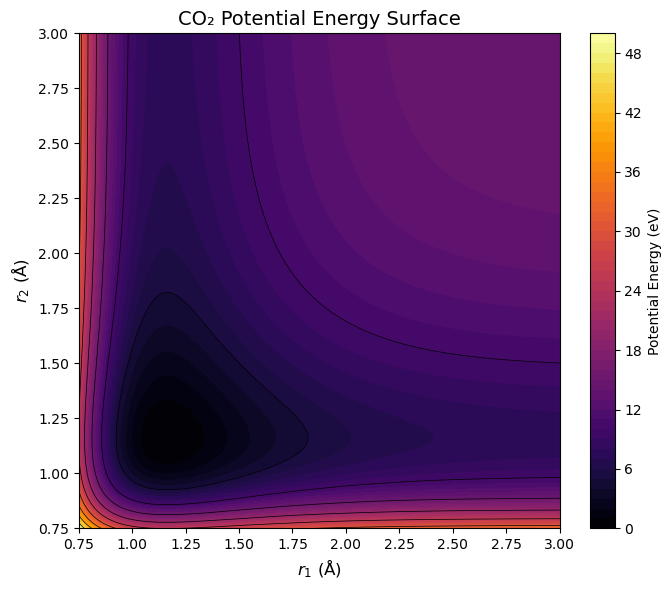

In [47]:
plt.figure(figsize=(7,6))

# Filling contour plot of the potential energy surface
contour = plt.contourf(R1, R2, V_total, levels=50, cmap='inferno')

# Adding colorbar (shows energy scale)
plt.colorbar(contour, label='Potential Energy (eV)')

# Labeling axes and title
plt.xlabel(r'$r_1$ (Å)', fontsize=12)
plt.ylabel(r'$r_2$ (Å)', fontsize=12)
plt.title('CO₂ Potential Energy Surface', fontsize=14)

#  Adding contour lines for clarity
plt.contour(R1, R2, V_total, levels=10, colors='black', linewidths=0.5)

plt.tight_layout()
plt.show()

Problem 3d

From the plot, the darkest region near the bottom left corner, represent lowest potential energy the minimum energy, at approximately (r₁, r₂) = (1.128 Å, 1.128 Å)
That minimum corresponds to the equilibrium geometry of the CO2 molecule, where both C-O bonds are at their equilibrium distance re.
The energy increases more steeply when one bond is stretched while the other is held fixed, as shown by the tightly packed contour lines along the axes.
In contrast, stretching both bonds simultaneously (moving diagonally) results in a more gradual energy rise, indicating a smoother potential along the symmetric-stretch direction.